# Ковалев Тимур
## Практика на тему "Разработка алгоритмов компьютерного зрения для решения прикладных задач"

Для начала импортируем все необходимые нам библиотеки

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

В следующем блоке определим константы, такие как размер изображений и бачей, количество эпох. Также пропишем пути к файлам, где находятся сами изображения

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_FOLDER_1 = 'data/HAM10000_images_part_1'
IMG_FOLDER_2 = 'data/HAM10000_images_part_2'
METADATA_FILE = 'data/HAM10000_metadata.csv'
IMG_FOLDERS = [IMG_FOLDER_1, IMG_FOLDER_2]

Реализуем класс, который будет получить изображения и объединять их с метками классов

In [ ]:
class SkinDataset(Dataset):
    def __init__(self, data_frame, img_folders, transform=None):
        self.data_frame = data_frame.reset_index(drop=True)
        self.img_folders = img_folders
        self.transform = transform
        
        self.data_frame['label'] = self.data_frame['dx'].apply(
            lambda x: 1 if x == 'mel' else 0
        )
    
    def __len__(self):
        return len(self.data_frame)
    
    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]
        img_id = row['image_id']
        
        image = None
        for folder in self.img_folders:
            img_path = os.path.join(folder, img_id + '.jpg')
            if os.path.exists(img_path):
                image = Image.open(img_path).convert('RGB')
                break
        
        if image is None:
            raise FileNotFoundError(f"Изображение {img_id}.jpg не найдено!")
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(row['label'], dtype=torch.float32)
        return image, label

Посмотрим на распределение данных по классам

In [6]:
metadata = pd.read_csv(METADATA_FILE)
print(f"Всего изображений в метаданных: {len(metadata)}")
print("\nРаспределение по классам:")
print(metadata['dx'].value_counts())

Всего изображений в метаданных: 10015

Распределение по классам:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
metadata = metadata.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(0.8 * len(metadata))
train_df = metadata.iloc[:split_idx].reset_index(drop=True)
val_df = metadata.iloc[split_idx:].reset_index(drop=True)

print(f"Обучающая выборка: {len(train_df)} изображений")
print(f"Валидационная выборка: {len(val_df)} изображений")
print(f"Меланом в train: {train_df['dx'].value_counts().get('mel', 0)}")
print(f"Меланом в val: {val_df['dx'].value_counts().get('mel', 0)}")


Обучающая выборка: 8012 изображений
Валидационная выборка: 2003 изображений
Меланом в train: 902
Меланом в val: 211


Теперь пропишем пайплайн, который будет применяться к каждому изображению. Для тренировочной выборки мы уменьшаем изображение, затем рандомно поворачиваем его и отражаем, чтобы у модели было больше разнообразных данных, и в конце переводим в массив и нормализуем. Для валидационной выборки мы не будем как-то искажать изображение, чтобы получить лучший результат

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Для валидации только базовые преобразования
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [9]:
train_dataset = SkinDataset(train_df, IMG_FOLDERS, transform=train_transform)
val_dataset = SkinDataset(val_df, IMG_FOLDERS, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Использовать для обучения будем преобученную ResNet, чтобы упростить задачу

In [10]:
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

model = model.to(DEVICE)

total_samples = len(train_dataset)
melanoma_samples = train_df['dx'].value_counts().get('mel', 0)
normal_samples = total_samples - melanoma_samples

pos_weight = torch.tensor([normal_samples / melanoma_samples]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/admin/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:24<00:00, 1.90MB/s]


In [11]:
best_accuracy = 0.0
history = {'train_loss': [], 'val_accuracy': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            outputs = model(images).squeeze()
            predictions = torch.sigmoid(outputs) >= 0.5
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    history['val_accuracy'].append(accuracy)
    
    print(f"\nЭпоха {epoch+1}/{EPOCHS}")
    print(f"  Потери: {avg_loss:.4f}")
    print(f"  Точность на валидации: {accuracy:.4f}")
    print(f"  Матрица ошибок:\n{cm}")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'best_model.pth')
        print("  ✓ Сохранена новая лучшая модель!")


Эпоха 1/10
  Потери: 0.9836
  Точность на валидации: 0.6740
  Матрица ошибок:
[[1163  629]
 [  24  187]]
  ✓ Сохранена новая лучшая модель!

Эпоха 2/10
  Потери: 0.8752
  Точность на валидации: 0.6985
  Матрица ошибок:
[[1212  580]
 [  24  187]]
  ✓ Сохранена новая лучшая модель!

Эпоха 3/10
  Потери: 0.8983
  Точность на валидации: 0.6640
  Матрица ошибок:
[[1147  645]
 [  28  183]]

Эпоха 4/10
  Потери: 0.9007
  Точность на валидации: 0.5482
  Матрица ошибок:
[[895 897]
 [  8 203]]

Эпоха 5/10
  Потери: 0.8311
  Точность на валидации: 0.7164
  Матрица ошибок:
[[1262  530]
 [  38  173]]
  ✓ Сохранена новая лучшая модель!

Эпоха 6/10
  Потери: 0.8407
  Точность на валидации: 0.7803
  Матрица ошибок:
[[1394  398]
 [  42  169]]
  ✓ Сохранена новая лучшая модель!

Эпоха 7/10
  Потери: 0.8200
  Точность на валидации: 0.7269
  Матрица ошибок:
[[1275  517]
 [  30  181]]

Эпоха 8/10
  Потери: 0.8185
  Точность на валидации: 0.7009
  Матрица ошибок:
[[1210  582]
 [  17  194]]

Эпоха 9/10
  По

Теперь посмотрим, какие результаты выдает лучшая модель на тестовых данных:

In [22]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs)
        predictions = probs >= 0.5
        
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

print("\nОтчет по классам:")
print(classification_report(all_labels, all_preds, target_names=['Здоров (benign)', 'Меланома (mel)']))

cm = confusion_matrix(all_labels, all_preds)
print(f"\nМатрица ошибок:")
print(f"                     Предсказано: Здоров   Предсказано: Меланома")
print(f"Реально Здоров:         {cm[0][0]:5d}                 {cm[0][1]:5d}")
print(f"Реально Меланома:       {cm[1][0]:5d}                 {cm[1][1]:5d}")

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"\nОсновные метрики:")
print(f"  Точность (Accuracy):     {accuracy:.4f}")
print(f"  Чувствительность:        {sensitivity:.4f} (нашли {sensitivity*100:.1f}% всех больных)")
print(f"  Специфичность:           {specificity:.4f} (правильно определили {specificity*100:.1f}% здоровых)")
print(f"  Точность позитивных:     {precision:.4f} (из предсказанных больных верных {precision*100:.1f}%)")


Отчет по классам:
                 precision    recall  f1-score   support

Здоров (benign)       0.97      0.78      0.86      1792
 Меланома (mel)       0.30      0.80      0.43       211

       accuracy                           0.78      2003
      macro avg       0.63      0.79      0.65      2003
   weighted avg       0.90      0.78      0.82      2003


Матрица ошибок:
                     Предсказано: Здоров   Предсказано: Меланома
Реально Здоров:          1394                   398
Реально Меланома:          42                   169

Основные метрики:
  Точность (Accuracy):     0.7803
  Чувствительность:        0.8009 (нашли 80.1% всех больных)
  Специфичность:           0.7779 (правильно определили 77.8% здоровых)
  Точность позитивных:     0.2981 (из предсказанных больных верных 29.8%)


Видно, что мы находим 80% всех больных, что достаточно неплохо. Можно также изменить порог классификации, тогда мы будем находить больше больных, но точность понизиться. В данном случае выбор порога будет зависеть от того, какое кол-во больных мы хотим верно определять

In [23]:
from sklearn.metrics import recall_score, precision_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
for thr in thresholds:
    preds = (np.array(all_probs) >= thr).astype(int)
    rec = recall_score(all_labels, preds)
    prec = precision_score(all_labels, preds)
    print(f"Порог {thr:.1f} | Recall: {rec:.3f} | Precision: {prec:.3f}")

Порог 0.2 | Recall: 0.953 | Precision: 0.210
Порог 0.3 | Recall: 0.910 | Precision: 0.232
Порог 0.4 | Recall: 0.877 | Precision: 0.264
Порог 0.5 | Recall: 0.801 | Precision: 0.298
Порог 0.6 | Recall: 0.640 | Precision: 0.326


Также посмотрим на графике лосса на тренировочной выборке, и точности на валидации. Видно, что после 6 эпохи модель уже начала переобучаться, поэтому график точности ушел вниз, а тренировочный лосс продолжал улучшаться. Мы выбрали лучшую модель, и теперь будем использовать ее для тестирования

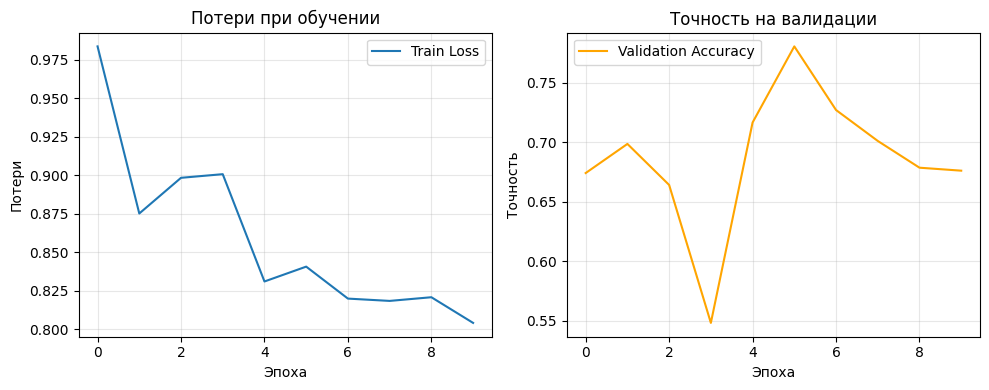

In [24]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.title('Потери при обучении')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title('Точность на валидации')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Также посмотрим на график ROC-AUC. В данном случае ROC-AUC равен 0.86, что достаточно хорошо для задач в медицинской сфере. Также учитывая, что в датасете был достаточно большой дисбаланс классов, мы получили достойный результат

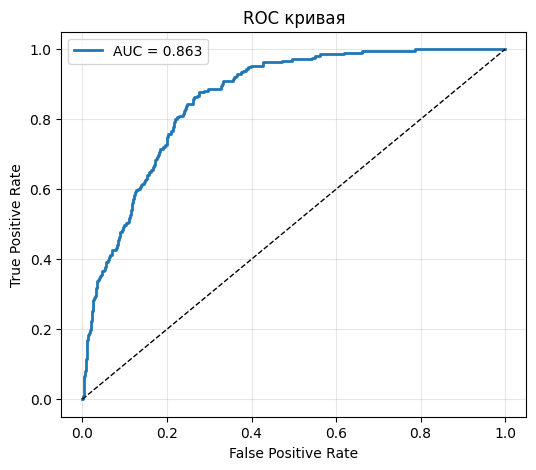

In [25]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC кривая')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
plt.close()

По матрице ошибок видно, что мы хорошо классифицируем здоровых людей, а также из 211 больных мелономой даем правильный ответ для 169 людей, что также является хорошим показателем

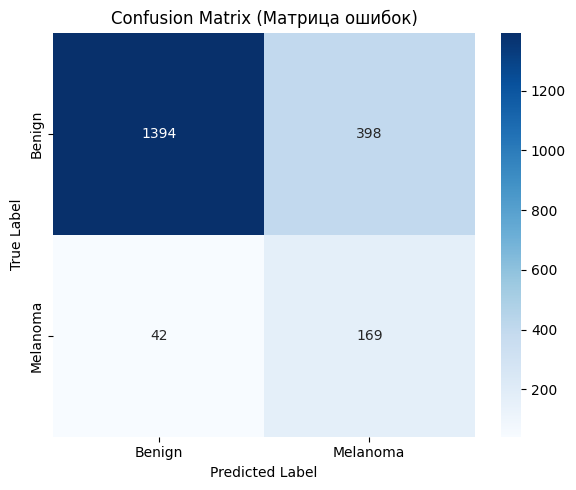

In [49]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=['Benign', 'Melanoma'], 
            yticklabels=['Benign', 'Melanoma'])
plt.title('Confusion Matrix (Матрица ошибок)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
plt.close()

Также можем посмотреть на распределение вероятностей, и можем увидеть, что модель правильно их предсказывает. Чем выше вероятность, тем больше доля больных, и наоборот

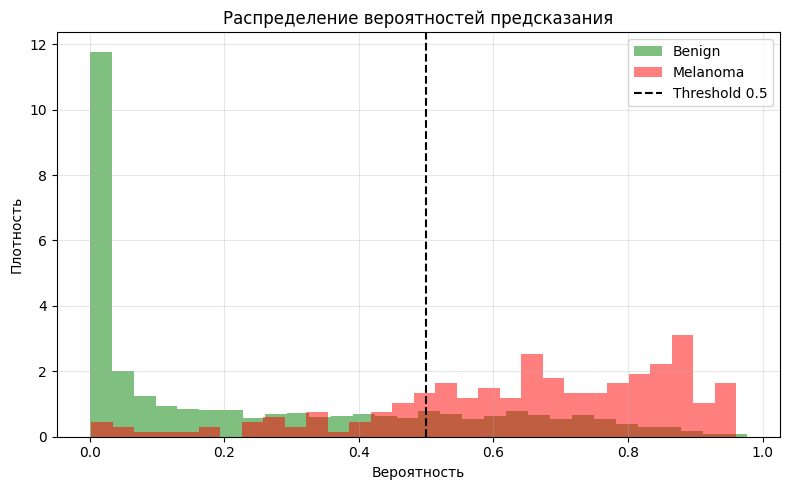

In [51]:
probs_arr = np.array(all_probs)
labels_arr = np.array(all_labels)
probs_benign = probs_arr[labels_arr == 0]
probs_melanoma = probs_arr[labels_arr == 1]

plt.figure(figsize=(8, 5))
plt.hist(probs_benign, bins=30, alpha=0.5, label='Benign', color='green', density=True)
plt.hist(probs_melanoma, bins=30, alpha=0.5, label='Melanoma', color='red', density=True)
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold 0.5')
plt.title('Распределение вероятностей предсказания')
plt.xlabel('Вероятность')
plt.ylabel('Плотность')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

Также выведим несколько примеров, чтобы убедиться, что модель действительно работает. В данном случае, модель из 8 изображений правильно классифицировала 7, из которых 2 это больные мелономой

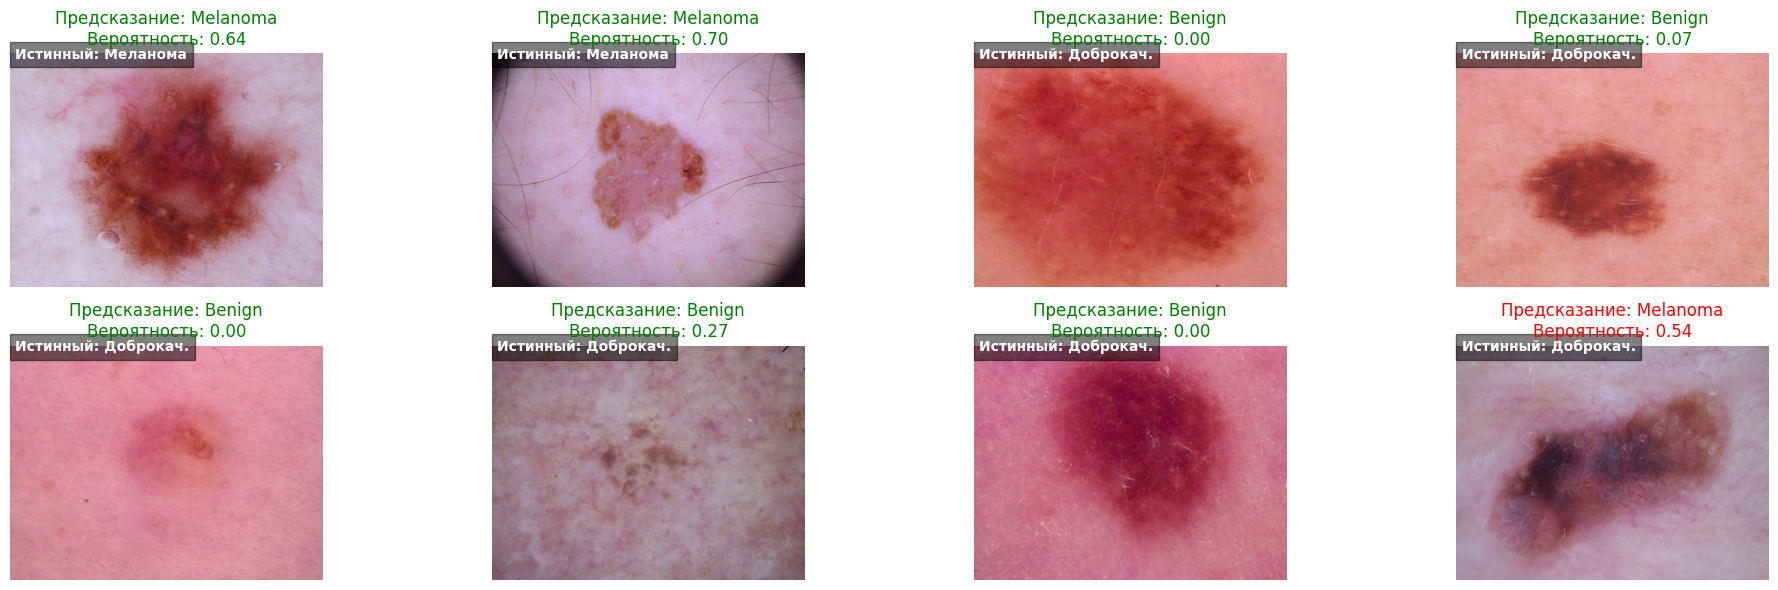

График сохранен как 'examples_visualization.png'


In [ ]:
import torchvision.models as models
import torchvision.transforms as transforms
import random

MODEL_PATH = 'best_model.pth'

model = models.resnet18()
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, 1)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

metadata = pd.read_csv(METADATA_FILE)

samples = metadata.sample(n=8)

plot_data = []

for idx, row in samples.iterrows():
    img_id = row['image_id']
    
    image = None
    for folder in IMG_FOLDERS:
        img_path = os.path.join(folder, f"{img_id}.jpg")
        if os.path.exists(img_path):
            image_raw = Image.open(img_path).convert('RGB')
            image_tensor = transform(image_raw).unsqueeze(0).to(DEVICE)
            break
    
    if image_raw is not None:
        with torch.no_grad():
            output = model(image_tensor)
            prob = torch.sigmoid(output).item()
            
            predicted_class = "Melanoma" if prob >= 0.5 else "Benign"
            true_class = row['dx']
            
            plot_data.append({
                'image': image_raw,
                'true_label': true_class,
                'pred_label': predicted_class,
                'probability': prob
            })

fig, axes = plt.subplots(2, 4, figsize=(20, 6))
axes = axes.flatten()

for i, data in enumerate(plot_data):
    img = data['image']
    true = data['true_label']
    pred = data['pred_label']
    prob = data['probability']
    
    axes[i].imshow(img)
    axes[i].axis('off')
    
    is_correct = (true == 'mel' and pred == 'Melanoma') or (true != 'mel' and pred == 'Benign')
    color = 'green' if is_correct else 'red'
    
    title = f"Предсказание: {pred}\nВероятность: {prob:.2f}"
    axes[i].set_title(title, color=color, fontsize=12)
    
    true_name = "Меланома" if true == 'mel' else "Доброкач."
    axes[i].text(10, 10, f"Истинный: {true_name}", color='white', 
                 fontsize=10, fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

plt.tight_layout()
plt.show()